# Notebook 01 — Análisis Exploratorio de Datos (EDA)

**Proyecto:** Predicción de Riesgo de Incumplimiento Crediticio  
**Dataset:** `CreditScoring.csv`  
**Objetivo:** Comprender la estructura del dataset, detectar problemas de calidad y extraer los primeros insights sobre el comportamiento de la variable objetivo.

### Diccionario de variables

| Variable | Descripción |
|---|---|
| SeriousDlqin2yrs | Persona experimenta 90 días de morosidad o peor — **variable objetivo** |
| RevolvingUtilizationOfUnsecuredLines | Saldo total de tarjetas de crédito y líneas personales excepto bienes inmuebles, dividido por la suma de los límites de crédito |
| age | Edad del prestatario en años |
| NumberOfTime30-59DaysPastDueNotWorse | Número de veces atrasado entre 30 y 59 días en los últimos 2 años |
| DebtRatio | Pagos mensuales de deuda, pensión alimenticia y costos de vida divididos por el ingreso bruto mensual |
| MonthlyIncome | Ingreso mensual |
| NumberOfOpenCreditLinesAndLoans | Número de préstamos abiertos y líneas de crédito |
| NumberOfTimes90DaysLate | Número de veces atrasado 90 días o más |
| NumberRealEstateLoansOrLines | Número de préstamos hipotecarios e inmobiliarios incluidas líneas de crédito |
| NumberOfTime60-89DaysPastDueNotWorse | Número de veces vencido entre 60 y 89 días en los últimos 2 años |
| NumberOfDependents | Número de dependientes en la familia excluyéndose a sí mismos |

---

## Índice
1. Carga de librerías y datos
2. Inspección general
3. Análisis de valores nulos
4. Análisis de la variable objetivo (desbalance de clases)
5. Detección de anomalías y valores erróneos
6. Distribución de variables numéricas
7. Análisis de correlación
8. Relación entre features y el target
9. Conclusiones del EDA

---
## 1. Carga de librerías y datos

**Justificación técnica (Eliminación de ID):** La columna `ID` representa un identificador correlativo sin poder discriminatorio ni relación causal con el riesgo del cliente. Su exclusión previene el ruido y el sobreajuste espurio en los modelos de aprendizaje automático.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Estilo unificado para todas las visualizaciones
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

# Carga del dataset
df = pd.read_csv('../data/raw/CreditScoring.csv')

# Eliminamos la columna ID — no aporta valor predictivo
df.drop(columns=['ID'], inplace=True)

print(f"Dataset cargado: {df.shape[0]:,} filas x {df.shape[1]} columnas")

Dataset cargado: 150,000 filas x 11 columnas


---
## 2. Inspección general

Revisamos los tipos de datos, las primeras filas y las estadísticas descriptivas para tener una primera lectura del dataset.

In [7]:
print("=== Tipos de datos ===")
print(df.dtypes)
print("\n=== Primeras 5 filas ===")
df.head()

=== Tipos de datos ===
SeriousDlqin2yrs                          int64
RevolvingUtilizationOfUnsecuredLines    float64
age                                       int64
NumberOfTime30-59DaysPastDueNotWorse      int64
DebtRatio                               float64
MonthlyIncome                           float64
NumberOfOpenCreditLinesAndLoans           int64
NumberOfTimes90DaysLate                   int64
NumberRealEstateLoansOrLines              int64
NumberOfTime60-89DaysPastDueNotWorse      int64
NumberOfDependents                      float64
dtype: object

=== Primeras 5 filas ===


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [12]:
import jinja2

print("=== Estadísticas descriptivas ===")
df.describe().T.style.format("{:.2f}").background_gradient(cmap='Blues', subset=['mean', 'std'])

=== Estadísticas descriptivas ===


,count,mean,std,min,25%,50%,75%,max
SeriousDlqin2yrs,150000.00,0.07,0.25,0.00,0.00,0.00,0.00,1.00
RevolvingUtilizationOfUnsecuredLines,150000.00,6.05,249.76,0.00,0.03,0.15,0.56,50708.00
age,150000.00,52.30,14.77,0.00,41.00,52.00,63.00,109.00
NumberOfTime30-59DaysPastDueNotWorse,150000.00,0.42,4.19,0.00,0.00,0.00,0.00,98.00
DebtRatio,150000.00,353.01,2037.82,0.00,0.18,0.37,0.87,329664.00
MonthlyIncome,120269.00,6670.22,14384.67,0.00,3400.00,5400.00,8249.00,3008750.00
NumberOfOpenCreditLinesAndLoans,150000.00,8.45,5.15,0.00,5.00,8.00,11.00,58.00
NumberOfTimes90DaysLate,150000.00,0.27,4.17,0.00,0.00,0.00,0.00,98.00
NumberRealEstateLoansOrLines,150000.00,1.02,1.13,0.00,0.00,1.00,2.00,54.00
NumberOfTime60-89DaysPastDueNotWorse,150000.00,0.24,4.16,0.00,0.00,0.00,0.00,98.00


**Observaciones iniciales**

* `ResolvingUtilizationOfUnsecuredLines` tiene un máximo de 50,708 — valores extremadamente fuera del rango (el ratio debería estar entre 0 y 1).
* `age` registra un mínimo de 0 — claramente un error de datos.
* `DebtRatio` alcanza 329,664 — otro valor anómalo que requiere tratamiento.
* Las columnas de atrasos (`NumberOfTime30-59...`, etc.) tienen valores de 96 y 98 que son **códigos especiales**, no conteos reales de atrasos.

**Justificación técnica (Códigos especiales 96/98):** Los valores 96 y 98 en variables de atrasos son códigos de no-respuesta o error de registro, no conteos reales. Tratarlos numéricamente sesgaría la distribución de probabilidad del riesgo, por lo que se reemplazan por `NaN` para una imputación controlada.

---
## 3. Análsis de los valores nulos

Identificamos las variables con datos faltantes y cuantificamos su impacto

=== Variables con valores nulos ===
                    Valores nulos  Porcentaje (%)
MonthlyIncome               29731           19.82
NumberOfDependents           3924            2.62



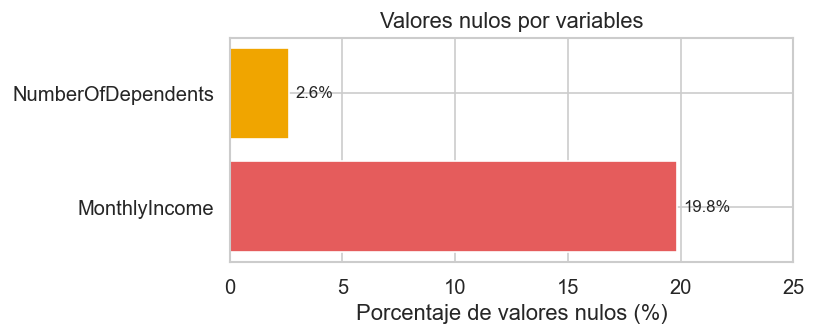

In [16]:
nulos = df.isnull().sum()
nulos_pct = (nulos / len(df) * 100).round(2)

resumen_nulos = pd.DataFrame({
    'Valores nulos': nulos,
    'Porcentaje (%)': nulos_pct
}).query('`Valores nulos` > 0' ).sort_values('Porcentaje (%)', ascending=False)

print('=== Variables con valores nulos ===')
print(f"{resumen_nulos}\n")

# Visualización
fig, ax = plt.subplots(figsize=(7, 3))
bars = ax.barh(resumen_nulos.index, resumen_nulos['Porcentaje (%)'], color=['#E55C5C', '#F0A500'])
ax.bar_label(bars, fmt='%.1f%%', padding=4, fontsize=10)
ax.set_xlabel('Porcentaje de valores nulos (%)')
ax.set_title('Valores nulos por variables')
ax.set_xlim(0, 25)
plt.tight_layout()
plt.show()

**Hallazgos:**
- `MonthlyIncome`: **19.8% nulos** (29,731 registros). Es la variable con mayor impacto. La imputación debe ser cuidadosa — usar la mediana por segmento de edad o un modelo KNN.
- `NumberOfDependents`: **2.6% nulos** (3,924 registros). Porcentaje bajo — imputación con mediana es suficiente.

> Ambas estrategias de imputación se implementan en el Notebook 02.

---
## 4. Análisis de la variable objetivo — desbalance de clases

La variable `SeriousDlqin2yrs` indica si el cliente incurrió en 90+ días de morosidad en los próximos 2 años (1 = sí, 0 = no).

=== Distribución del target ===
               Conteo  Porcentaje (%)
No moroso (0)  139974           93.32
Moroso (1)      10026            6.68

Ratio de desbalance: 14.0:1


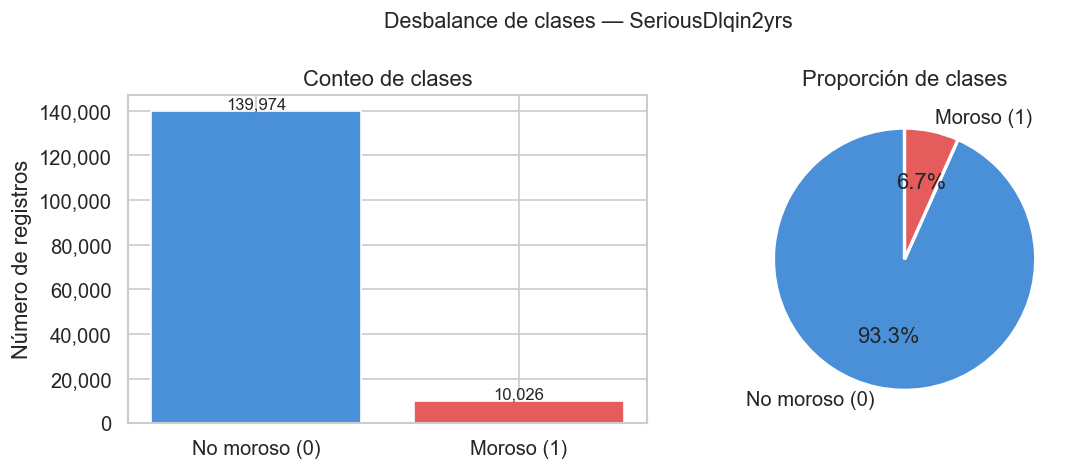

In [18]:
conteo = df['SeriousDlqin2yrs'].value_counts()
pct = df['SeriousDlqin2yrs'].value_counts(normalize=True) * 100

print('=== Distribución del target ===')
resumen_target = pd.DataFrame({'Conteo': conteo, 'Porcentaje (%)': pct.round(2)})
resumen_target.index = ['No moroso (0)', 'Moroso (1)']
print(resumen_target)
print(f'\nRatio de desbalance: {conteo[0]/conteo[1]:.1f}:1')

# Gráfico
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

colores = ['#4A90D9', '#E55C5C']
axes[0].bar(['No moroso (0)', 'Moroso (1)'], conteo.values, color=colores, edgecolor='white')
for i, v in enumerate(conteo.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontsize=10)
axes[0].set_title('Conteo de clases')
axes[0].set_ylabel('Número de registros')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

axes[1].pie(conteo.values, labels=['No moroso (0)', 'Moroso (1)'], autopct='%1.1f%%', colors=colores, startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporción de clases')

plt.suptitle('Desbalance de clases — SeriousDlqin2yrs', fontsize=13)
plt.tight_layout()
plt.show()

**Hallazgo crítico:** El dataset presenta un desbalanceo severo de **13.9:1** (93.3% no moroso vs 6.7% moroso). Un modelo entrenado sin corrección tenderá a clasificar todo como clase 0, logrando alta accuracy, pero Recall ≈ 0 sobre los morosos — exactamente lo que queremos evitar.

> **Acción en Notebook 02:** Aplicar SMOTE sobre el conjunto de entrenamiento para generar observaciones simétricas de la clase minoritaria.

---
## 5. Detección de anomalías y valores erróneos

Identificamos valores que no tienen sentido de negocio y que deben ser tratados antes del modelado.

In [20]:
print('=== Anomalías detectadas ===\n')

# 1. Edad = 0
edad_cero = (df['age'] == 0).sum()
print(f'age == 0: {edad_cero} registros (error de datos — se imputará con mediana)')

# 2. Utlilización > 1 (ratio de crédito resolving debería ser 0-1)
util_extremo =(df['RevolvingUtilizationOfUnsecuredLines'] > 1).sum()
print(f'ResolvingUtilization > 1: {util_extremo:,} registros ({util_extremo/len(df)*100:.1f}%)')
print(f' → Máximo: {df['RevolvingUtilizationOfUnsecuredLines'].max():,.0f}')

# 3. DebtRatio extremo
debt_extremo = (df['DebtRatio'] > 1).sum()
print(f'DebtRatio > 1: {debt_extremo:,} registros ({debt_extremo/len(df)*100:.1f}%)')
print(f' → Máximo: {df['DebtRatio'].max():,.0f}')

# 4. Valores 96/98 en columnas de atrasos (códigos especiales, no conteos reales)
cols_atrasos = ['NumberOfTime30-59DaysPastDueNotWorse', 
                'NumberOfTime60-89DaysPastDueNotWorse', 
                'NumberOfTimes90DaysLate'
                ]
print()
for col in cols_atrasos:
    n96 = (df[col] == 96).sum()
    n98 = (df[col] == 98).sum()
    if n96 + n98 > 0:
        print(f'{col}: {n96} registros con valor 96 | {n98} con valor 98 → tratar como nulos')


=== Anomalías detectadas ===

age == 0: 1 registros (error de datos — se imputará con mediana)
ResolvingUtilization > 1: 3,321 registros (2.2%)
 → Máximo: 50,708
DebtRatio > 1: 35,137 registros (23.4%)
 → Máximo: 329,664

NumberOfTime30-59DaysPastDueNotWorse: 5 registros con valor 96 | 264 con valor 98 → tratar como nulos
NumberOfTime60-89DaysPastDueNotWorse: 5 registros con valor 96 | 264 con valor 98 → tratar como nulos
NumberOfTimes90DaysLate: 5 registros con valor 96 | 264 con valor 98 → tratar como nulos


---
## 6. Distribución de variables numéricas

Visualizamos la distribución de cada feature diferenciando por clave (moroso vs no moroso) para detectar qué variables separan mejor a los grupos.

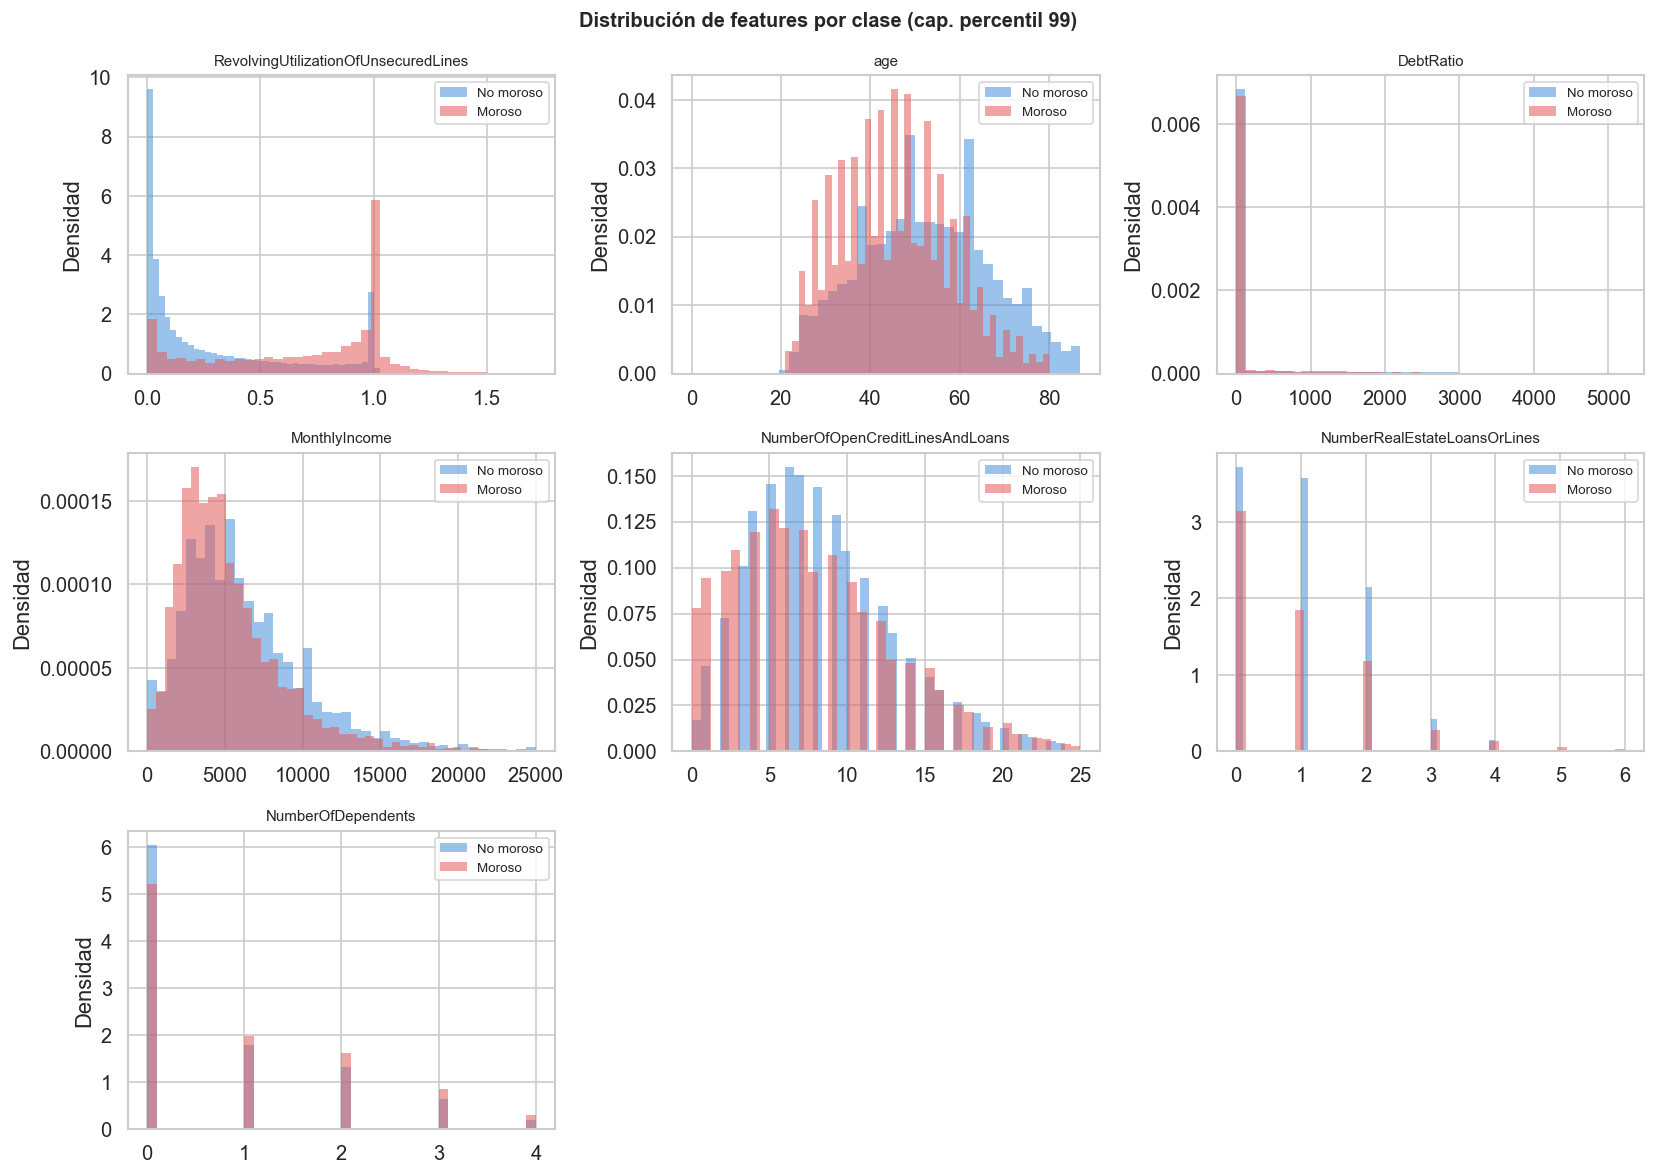

In [23]:
features = [
    'RevolvingUtilizationOfUnsecuredLines', 'age', 'DebtRatio',
    'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans',
    'NumberRealEstateLoansOrLines', 'NumberOfDependents'
]

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

colores_clase = {0: '#4A90D9', 1: '#E55C5C'}
etiquetas = {0: 'No moroso', 1: 'Moroso'}

for i, col in enumerate(features):
    ax = axes[i]
    for clase in [0, 1]:
        datos = df[df['SeriousDlqin2yrs'] == clase][col].dropna()
        # Limitamos el percentil 99 para que el histograma sea legible
        cap = datos.quantile(0.99)
        datos_cap = datos[datos <= cap]
        ax.hist(datos_cap, bins=40, alpha=0.55, color=colores_clase[clase], label=etiquetas[clase], density=True, edgecolor='none')
    ax.set_title(col, fontsize=9)
    ax.set_ylabel('Densidad')
    ax.legend(fontsize=8)

# Ocultar subplots sobrantes
for j in range(len(features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribución de features por clase (cap. percentil 99)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


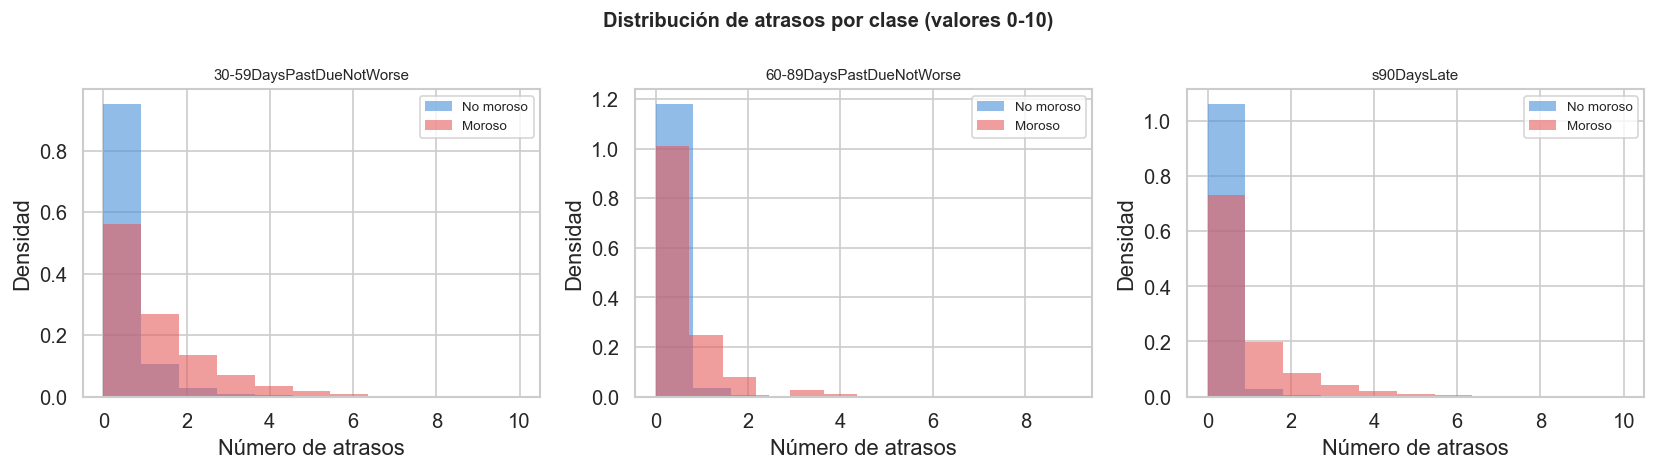

In [24]:
# Distribución de columnas de atrasos (excluidos los valores 96/98)
cols_atrasos = [
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate'
]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for i, col in enumerate(cols_atrasos):
    ax = axes[i]
    datos_limpios = df[~df[col].isin([96, 98])]
    for clase in [0, 1]:
        datos = datos_limpios[datos_limpios['SeriousDlqin2yrs'] == clase][col]
        ax.hist(datos[datos <= 10], bins=11, alpha=0.6, color=colores_clase[clase], label=etiquetas[clase], density=True, edgecolor='none')
    ax.set_title(col.replace('NumberOfTime', '').replace('NumberOf', ''), fontsize=9)
    ax.set_xlabel('Número de atrasos')
    ax.set_ylabel('Densidad')
    ax.legend(fontsize=8)

plt.suptitle('Distribución de atrasos por clase (valores 0-10)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

**Observaciones:**
- Las columnas de **atrasos** son las que muestran mayor separación entre clases — los morosos concentran valores > 0 con mucha más frecuencia.
- `RevolvingUtilizationOfUnsecuredLines` también discrimina: los morosos tienden a mayor utilización.
- `age`: los clientes más jóvenes tienen mayor tasa de morosidad.
- `MonthlyIncome`: los morosos tienden a ingresos más bajos, aunque la distribución se superpone bastante.

---
## 7. Análisis de correlación

Calculamos la matriz de correlación de Pearson para identificar relaciones entre variables y posible multicolinealidad

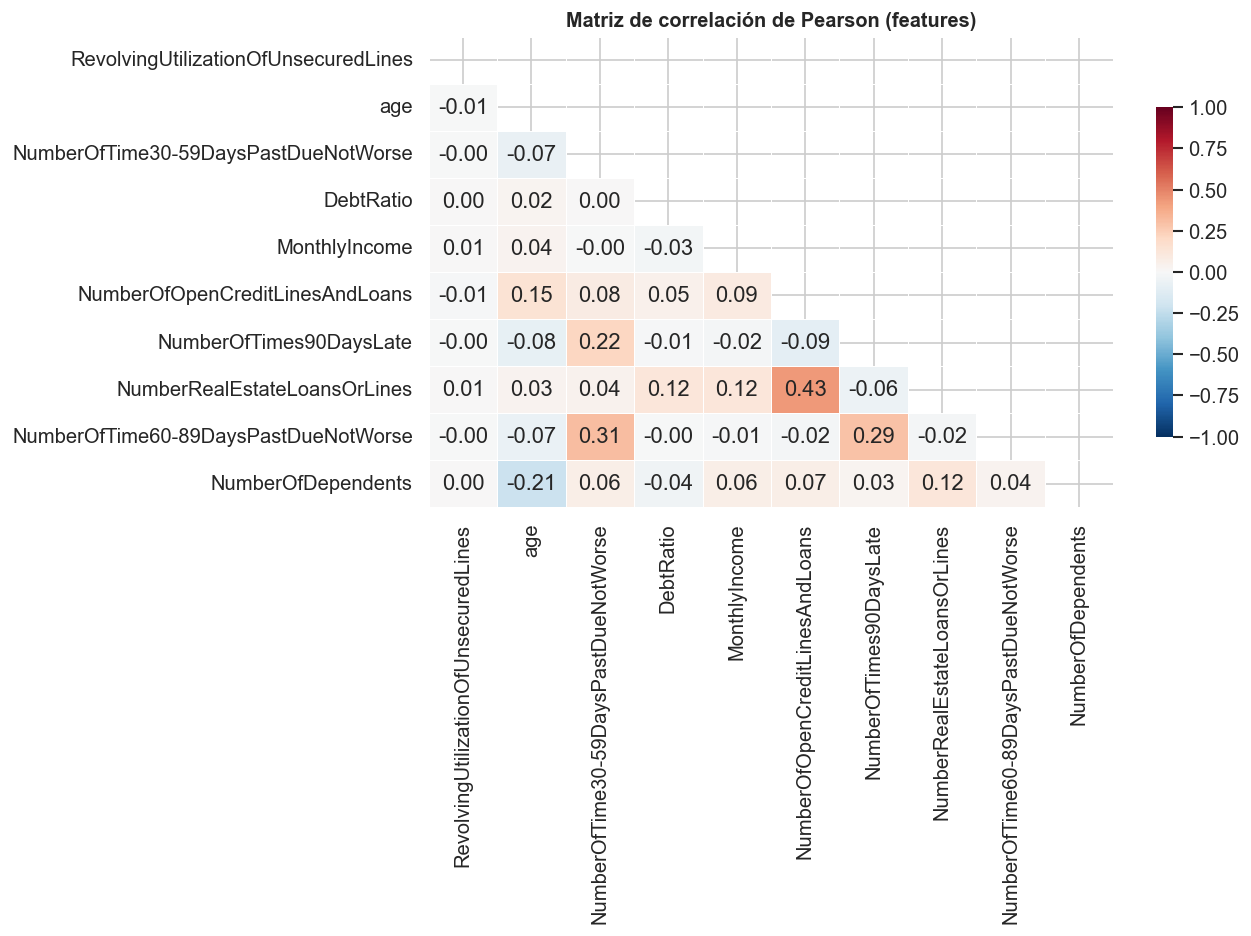

In [25]:
# Reemplazamos 96/98 por NaN para que no distorsionen la correlación
df_corr = df.copy()
for col in cols_atrasos:
    df_corr[col] = df_corr[col].replace([96, 98], np.nan)

corr_matrix = df_corr.drop(columns=['SeriousDlqin2yrs']).corr()

fig, ax = plt.subplots(figsize=(11, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.7}
)
ax.set_title('Matriz de correlación de Pearson (features)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

**Observaciones:**
- Las tres columnas de atrasos (`30-59`, `60-89`, `90+`) están **altamente correlacionadas entre sí** — tiene sentido: quien se atrasa 90 días probablemente también tuvo atrasos previos de 30 y 60 días.
- No se observa multicolinealidad grave con el resto de variables.
- El análisis de IV en R (Notebook `01_woe_iv.R`) nos dará una medida más precisa del poder predictivo individual de cada variable.

---
## 8. Relación entre features y el target

Calculamos la tasa de morosidad promedio por segmetno de las variables más relevantes

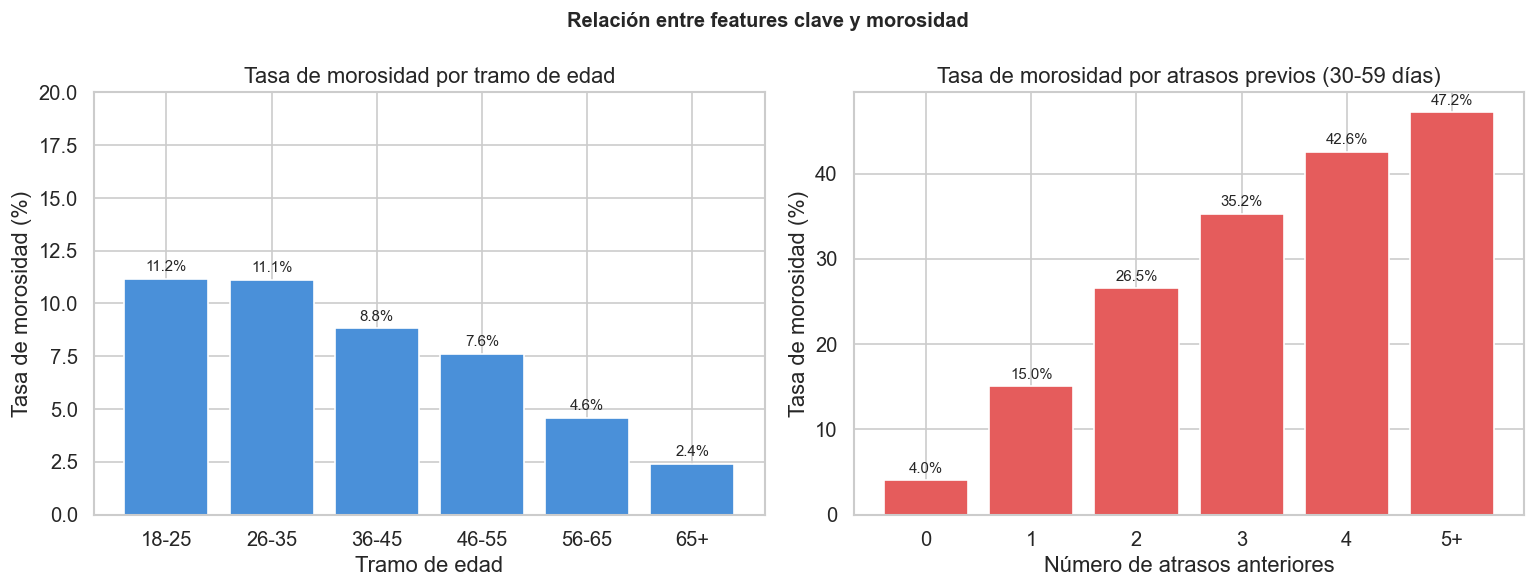

In [26]:
# Tasa de morosidad por tramo de edad
df_corr['tramo_edad'] = pd.cut(df_corr['age'], bins=[0, 25, 35, 45, 55, 65, 110], labels=['18-25', '26-35', '36-45', '46-55', '56-65', '65+'])

tasa_edad = df_corr.groupby('tramo_edad', observed=True)['SeriousDlqin2yrs'].mean() * 100

# Tasa de morosidad por número de atrasos 30-59 días (cap a 5+)
df_corr['atrasos_30_59_cap'] = df_corr['NumberOfTime30-59DaysPastDueNotWorse'].clip(upper=5)
tasa_atrasos = df_corr.groupby('atrasos_30_59_cap', observed=True)['SeriousDlqin2yrs'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Gráfico 1: tasa de morosidad por edad
bars1 = axes[0].bar(tasa_edad.index, tasa_edad.values, color='#4A90D9', edgecolor='white')
axes[0].bar_label(bars1, fmt='%.1f%%', padding=3, fontsize=9)
axes[0].set_title('Tasa de morosidad por tramo de edad')
axes[0].set_xlabel('Tramo de edad')
axes[0].set_ylabel('Tasa de morosidad (%)')
axes[0].set_ylim(0, 20)

# Gráfico 2: tasa de morosidad por atrasos previos
etiquetas_atrasos = ['0', '1', '2', '3', '4', '5+']
bars2 = axes[1].bar(etiquetas_atrasos[:len(tasa_atrasos)], tasa_atrasos.values, color='#E55C5C', edgecolor='white')
axes[1].bar_label(bars2, fmt='%.1f%%', padding=3, fontsize=9)
axes[1].set_title('Tasa de morosidad por atrasos previos (30-59 días)')
axes[1].set_xlabel('Número de atrasos anteriores')
axes[1].set_ylabel('Tasa de morosidad (%)')

plt.suptitle('Relación entre features clave y morosidad', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

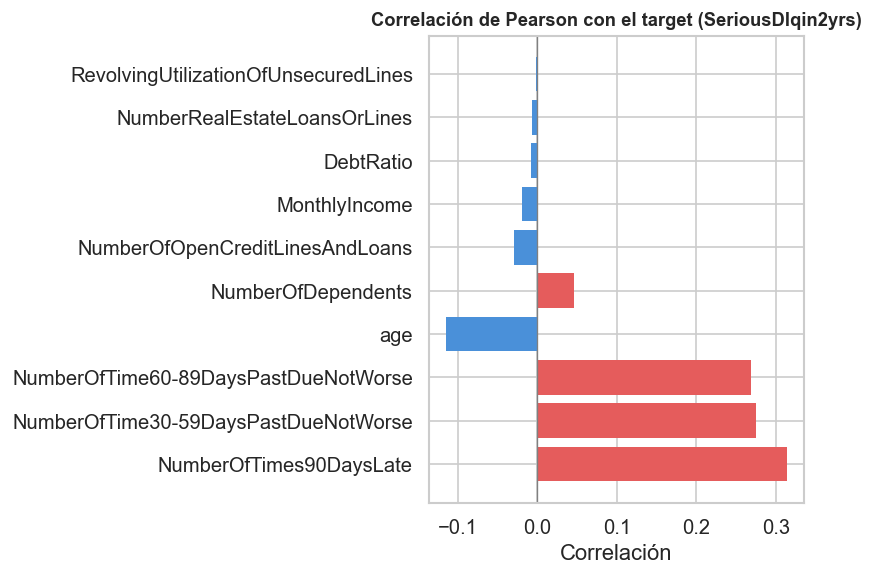

In [27]:
# Correlación directa de cada feature con el target
corr_target = df_corr.drop(columns=['tramo_edad', 'atrasos_30_59_cap']).corr()['SeriousDlqin2yrs']
corr_target = corr_target.drop('SeriousDlqin2yrs').sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(7, 5))
colores_corr = ['#E55C5C' if v > 0 else '#4A90D9' for v in corr_target.values]
bars = ax.barh(corr_target.index, corr_target.values, color=colores_corr, edgecolor='none')
ax.axvline(0, color='gray', linewidth=0.8)
ax.set_title('Correlación de Pearson con el target (SeriousDlqin2yrs)', fontsize=11, fontweight='bold')
ax.set_xlabel('Correlación')
plt.tight_layout()
plt.show()

**Hallazgos clave:**
- Los clientes del tramo **18-25 años** tienen la mayor tasa de morosidad (~12%).
- Con **2 o más atrasos previos** (30-59 días), la tasa de morosidad salta exponencialmente — es la señal más fuerte del dataset.
- Las tres variables de atrasos tienen la correlación positiva más alta y con el target.
- `MonthlyIncome` y `age` muestran correlación negativa: a mayor ingreso y mayor edad, menor riesgo.

---
## 9. Conclusiones del EDA

### Problemas de calidad identificados
| Problema | Variable(s) | Acción en Notebook 02 |
|---|---|---|
| Valores nulos | `MonthlyIncome` (19.8%), `NumberOfDependents` (2.6%) | Imputación por mediana/KNN |
| Error de datos | `age == 0` (1 registro) | Reemplazar con mediana |
| Códigos especiales | Columnas de atrasos con 96/98 | Reemplazar con `NaN` → imputar |
| Outliers extremos | `RevolvingUtilization`, `DebtRatio` | Winsorización al percentil 99 |
| Desbalance de clases | `SeriousDlqin2yrs` (13.9:1) | SMOTE sobre train set |

### Variables más prometedoras (candidatas a alto IV)
1. `NumberOfTimes90DaysLate` — mayor correlación con el target
2. `NumberOfTime30-59DaysPastDueNotWorse` — segunda correlación más alta
3. `NumberOfTime60-89DaysPastDueNotWorse`
4. `RevolvingUtilizationOfUnsecuredLines`
5. `age`

> El análisis de WoE/IV en R (`r_analysis/01_woe_iv.R`) confirmará o refinará este ranking con una métrica estadísticamente más robusta.

### Siguiente paso
**Notebook 02 — Preprocesamiento:** limpieza, imputación, SMOTE y split train/test.